<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
#!pip install pandas 
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
import requests

# Step 1: Download the dataset
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
r = requests.get(url)

with open('survey-data.csv', 'wb') as f:
    f.write(r.content)

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


In [3]:
bub_age_freq = df[['Age', 'SOPartFreq', 'JobSat']]
bub_age_freq = bub_age_freq.dropna()
bub_age_freq = bub_age_freq[bub_age_freq['Age'] != 'Prefer not to say']
bub_age_freq = bub_age_freq.sort_values('JobSat')
bub_age_freq['JobSat'] = bub_age_freq['JobSat'].astype(int)
bub_age_freq.head()

,Age,SOPartFreq,JobSat
6091,45-54 years old,A few times per month or weekly,0
16630,25-34 years old,I have never participated in Q&A on Stack Over...,0
45720,25-34 years old,Less than once per month or monthly,0
16572,25-34 years old,I have never participated in Q&A on Stack Over...,0
17032,18-24 years old,A few times per week,0


In [4]:
bins = [0, 3, 7, 10]
levels = ['Low', 'Medium', 'High']
bub_age_freq['JobSatLevel'] = pd.cut(bub_age_freq['JobSat'], bins = bins, labels = levels, include_lowest = True)

In [5]:
bub_age_freq.tail()

,Age,SOPartFreq,JobSat,JobSatLevel
45365,35-44 years old,Less than once per month or monthly,10,High
45433,35-44 years old,A few times per month or weekly,10,High
45510,25-34 years old,I have never participated in Q&A on Stack Over...,10,High
18,25-34 years old,A few times per week,10,High
65095,35-44 years old,I have never participated in Q&A on Stack Over...,10,High


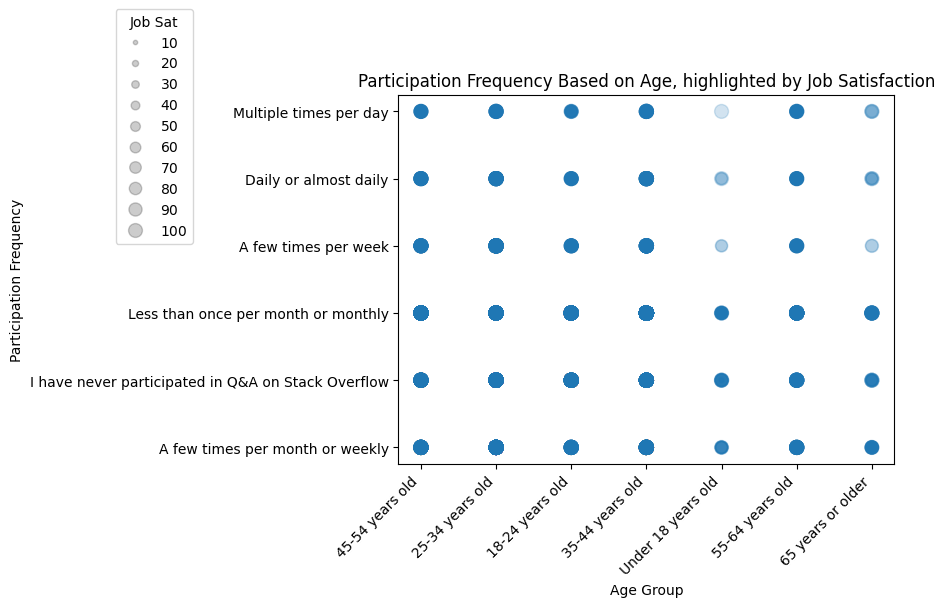

In [6]:
fig, ax = plt.subplots()

scatter = ax.scatter(x = bub_age_freq['Age'],
                     y = bub_age_freq['SOPartFreq'],
                     s = bub_age_freq['JobSat']*10,
                     alpha = 0.2)

legend = ax.legend(*scatter.legend_elements(prop = 'sizes'),
                   bbox_to_anchor= (-0.4, 1.25), title='Job Sat')

plt.xlabel('Age Group')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Participation Frequency')
plt.title('Participation Frequency Based on Age, highlighted by Job Satisfaction')
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


In [7]:
bub_comp_sat = df[['ConvertedCompYearly', 'JobSat', 'Age']]
bub_comp_sat = bub_comp_sat.dropna()
bub_comp_sat = bub_comp_sat.sort_values('Age')
bub_comp_sat.head()

,ConvertedCompYearly,JobSat,Age
72,7322.0,10.0,18-24 years old
426,50000.0,8.0,18-24 years old
542,3618.0,2.0,18-24 years old
613,5982.0,4.0,18-24 years old
631,128129.0,9.0,18-24 years old


In [8]:
q1 = bub_comp_sat['ConvertedCompYearly'].quantile(0.25)
q3 = bub_comp_sat['ConvertedCompYearly'].quantile(0.75)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
bub_comp_sat = bub_comp_sat[bub_comp_sat['ConvertedCompYearly'] < upper_bounds]
print(bub_comp_sat['ConvertedCompYearly'].describe())
print(bub_comp_sat.head())

count     15437.000000
mean      72033.364060
std       51199.549071
min           1.000000
25%       32222.000000
50%       64444.000000
75%      101910.000000
max      220207.000000
Name: ConvertedCompYearly, dtype: float64
     ConvertedCompYearly  JobSat              Age
72                7322.0    10.0  18-24 years old
426              50000.0     8.0  18-24 years old
542               3618.0     2.0  18-24 years old
613               5982.0     4.0  18-24 years old
631             128129.0     9.0  18-24 years old


In [9]:
bub_comp_sat['Age'].value_counts()

Age
25-34 years old       7171
35-44 years old       4101
18-24 years old       2248
45-54 years old       1385
55-64 years old        446
65 years or older       52
Under 18 years old      27
Prefer not to say        7
Name: count, dtype: int64

In [10]:
labels, uniques = pd.factorize(bub_comp_sat['Age']) # enumerating the different age groups
legend_elements = dict(zip(uniques, range(0, 8))) # create a dictionary pairing uniques with their labels for legend

legend_elements

{'18-24 years old': 0,
 '25-34 years old': 1,
 '35-44 years old': 2,
 '45-54 years old': 3,
 '55-64 years old': 4,
 '65 years or older': 5,
 'Prefer not to say': 6,
 'Under 18 years old': 7}

In [11]:
bub_comp_sat['Age_int'] = bub_comp_sat['Age'].map(legend_elements)
bub_comp_sat['Age_int'].value_counts()

Age_int
1    7171
2    4101
0    2248
3    1385
4     446
5      52
7      27
6       7
Name: count, dtype: int64

In [12]:
uniques

Index(['18-24 years old', '25-34 years old', '35-44 years old',
       '45-54 years old', '55-64 years old', '65 years or older',
       'Prefer not to say', 'Under 18 years old'],
      dtype='str')

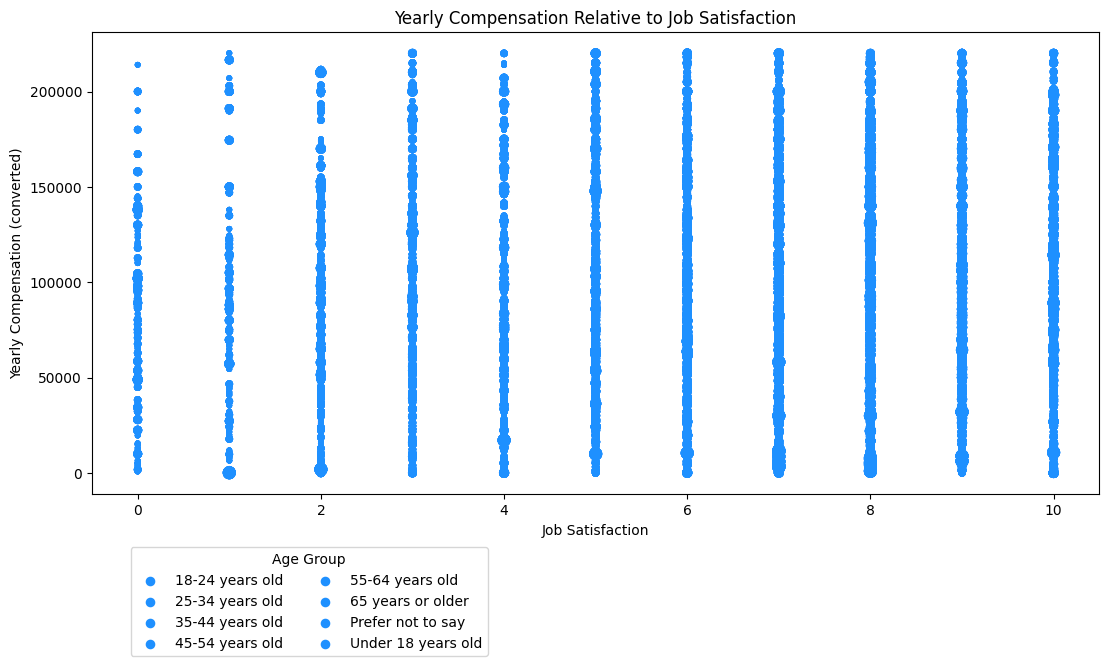

In [13]:
fig, ax = plt.subplots(figsize = (13,6))

for age in list(uniques):
    scatter = plt.scatter(x = bub_comp_sat['JobSat'],
                          y = bub_comp_sat['ConvertedCompYearly'],
                          s = bub_comp_sat['Age_int']*10,
                          color = 'dodgerblue')

    legend = ax.legend(*scatter.legend_elements(prop = 'sizes'))
    ax.legend(title = 'Age Group',
              labels = legend_elements.keys(),
              bbox_to_anchor = (0.4, -0.1),
              ncol = 2)


plt.xlabel('Job Satisfaction')
plt.ylabel('Yearly Compensation (converted)')
plt.title('Yearly Compensation Relative to Job Satisfaction')
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



In [14]:
bub_tech_age = df[['LanguageHaveWorkedWith', 'Age']]
bub_tech_age = bub_tech_age.dropna()
bub_tech_age = bub_tech_age[bub_tech_age['Age'] != 'Prefer not to say']
bub_tech_age.head()

,LanguageHaveWorkedWith,Age
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,35-44 years old
2,C#,45-54 years old
3,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,18-24 years old
4,C++;HTML/CSS;JavaScript;Lua;Python;Rust,18-24 years old
5,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,Under 18 years old


In [15]:
bub_tech = bub_tech_age['LanguageHaveWorkedWith'].str.split(';').explode() # explode lists in column
bub_tech_age_exp = pd.DataFrame(bub_tech) # creating dataframe for exploded data
bub_tech_age_exp = bub_tech_age_exp.join(bub_tech_age['Age'], # joining age on (repeated) indices from explode function
                                         how = 'left')      # to pair age with each language in each row's list
bub_tech_age_exp = bub_tech_age_exp.reset_index(drop = True) # resetting index
bub_tech_age_exp.head(10)

,LanguageHaveWorkedWith,Age
0,Bash/Shell (all shells),35-44 years old
1,Go,35-44 years old
2,HTML/CSS,35-44 years old
3,Java,35-44 years old
4,JavaScript,35-44 years old
5,Python,35-44 years old
6,TypeScript,35-44 years old
7,C#,45-54 years old
8,C,18-24 years old
9,C++,18-24 years old


In [16]:
bub_groupby = bub_tech_age_exp.groupby(['Age', 'LanguageHaveWorkedWith']).size().reset_index(name = 'Size')
bub_groupby

,Age,LanguageHaveWorkedWith,Size
0,18-24 years old,Ada,117
1,18-24 years old,Apex,71
2,18-24 years old,Assembly,1305
3,18-24 years old,Bash/Shell (all shells),4069
4,18-24 years old,C,4309
...,...,...,...
338,Under 18 years old,TypeScript,718
339,Under 18 years old,VBA,44
340,Under 18 years old,Visual Basic (.Net),77
341,Under 18 years old,Zephyr,2


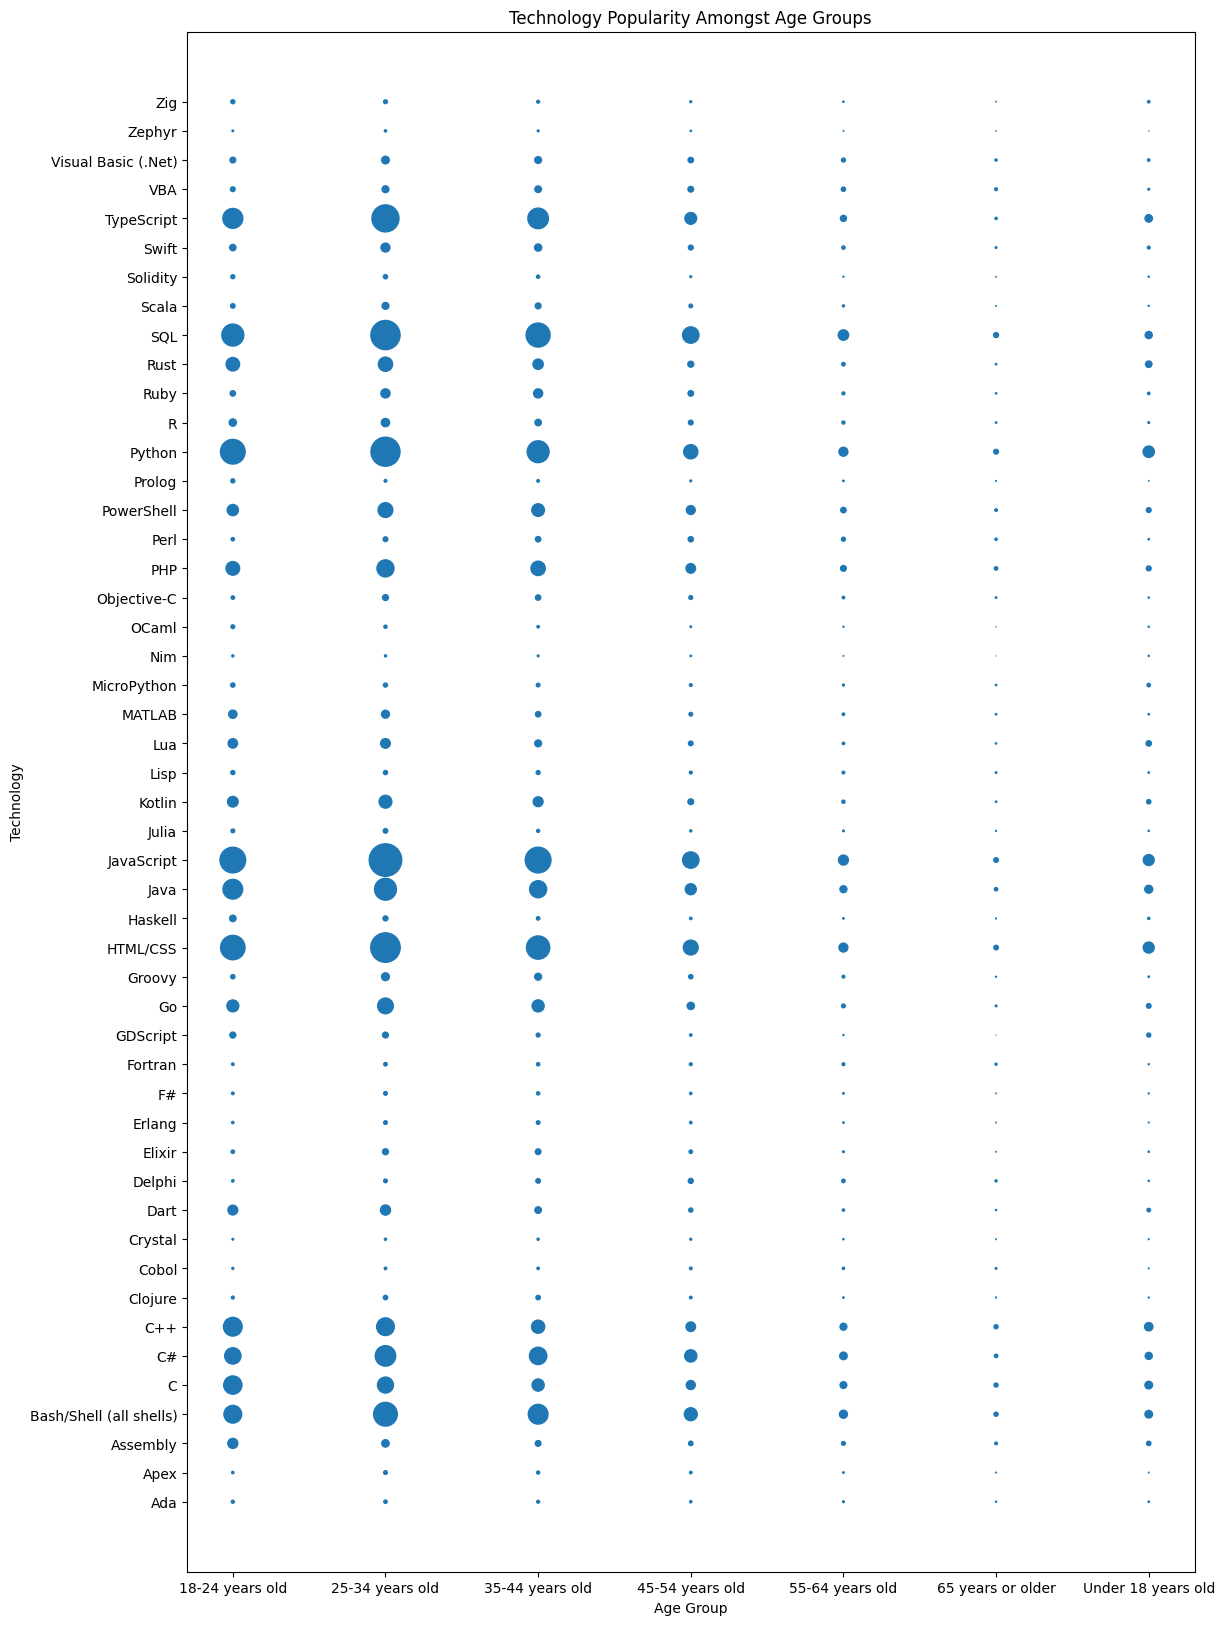

In [17]:
age_list = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old',
            '45-54 years old', '55-64 years old', '65 years or older']

fig, ax = plt.subplots(figsize = (13, 20))

plt.scatter(x=bub_groupby['Age'],
            y=bub_groupby['LanguageHaveWorkedWith'],
            s=bub_groupby['Size']/25)

plt.xlabel('Age Group')
plt.ylabel('Technology')
plt.title('Technology Popularity Amongst Age Groups')

plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


In [18]:
bub_pref_sat = df[['DatabaseWantToWorkWith', 'JobSat']] # creating df with the two columns
bub_pref_sat = bub_pref_sat.dropna() # dropping na values
bub_pref_sat['Pref DB'] = bub_pref_sat['DatabaseWantToWorkWith'].str.split(';') # splitting lists into new column of lists
bub_pref_sat = bub_pref_sat.explode('Pref DB') # exploding the column of lists
bub_pref_sat = bub_pref_sat.drop('DatabaseWantToWorkWith', axis=1) # dropping unsplit column
bub_pref_sat = bub_pref_sat.reset_index(drop = True)
bub_pref_sat

,JobSat,Pref DB
0,8.0,Elasticsearch
1,8.0,MongoDB
2,8.0,PostgreSQL
3,8.0,SQLite
4,8.0,MySQL
...,...,...
69348,8.0,Microsoft Access
69349,8.0,MongoDB
69350,8.0,MySQL
69351,8.0,PostgreSQL


In [19]:
bub_pref_sat = bub_pref_sat.groupby(['JobSat', 'Pref DB']).size().reset_index(name='Sizes')
bub_pref_sat

,JobSat,Pref DB,Sizes
0,0.0,BigQuery,15
1,0.0,Cassandra,23
2,0.0,Clickhouse,8
3,0.0,Cloud Firestore,6
4,0.0,Cockroachdb,8
...,...,...,...
377,10.0,SQLite,545
378,10.0,Snowflake,84
379,10.0,Solr,27
380,10.0,Supabase,106


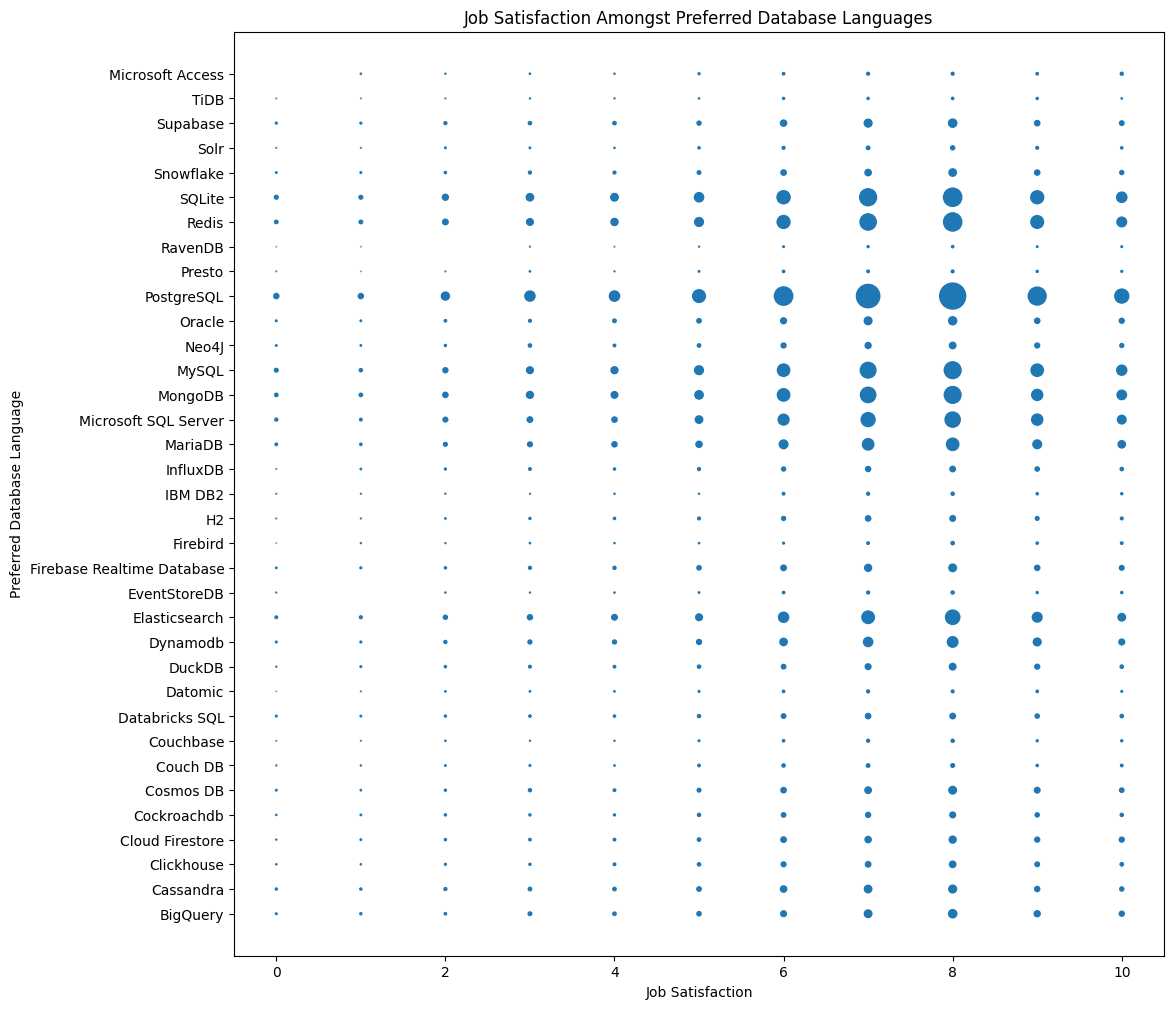

In [20]:
plt.figure(figsize = (12, 12))
plt.scatter(x=bub_pref_sat['JobSat'],
            y=bub_pref_sat['Pref DB'],
            s=bub_pref_sat['Sizes']/10)
plt.xlabel('Job Satisfaction')
plt.ylabel('Preferred Database Language')
plt.title('Job Satisfaction Amongst Preferred Database Languages')
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


In [21]:
bub_comp_dev = df[['ConvertedCompYearly', 'DevType', 'JobSat']]
bub_comp_dev = bub_comp_dev.dropna()
bub_comp_dev

,ConvertedCompYearly,DevType,JobSat
72,7322.0,Data scientist or machine learning specialist,10.0
379,91295.0,Data scientist or machine learning specialist,10.0
389,110000.0,Student,10.0
392,161044.0,Engineering manager,7.0
398,195000.0,"Developer, full-stack",5.0
...,...,...,...
41175,15637.0,"Developer, full-stack",6.0
41178,9711.0,"Developer, full-stack",0.0
41184,170000.0,Project manager,9.0
41186,12000.0,"Developer, full-stack",3.0


In [22]:
q1 = bub_comp_dev['ConvertedCompYearly'].quantile(0.25) # removing outliers for this column for vis as usual
q3 = bub_comp_dev['ConvertedCompYearly'].quantile(0.75)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
bub_comp_dev = bub_comp_dev[bub_comp_dev['ConvertedCompYearly'] <= upper_bounds]

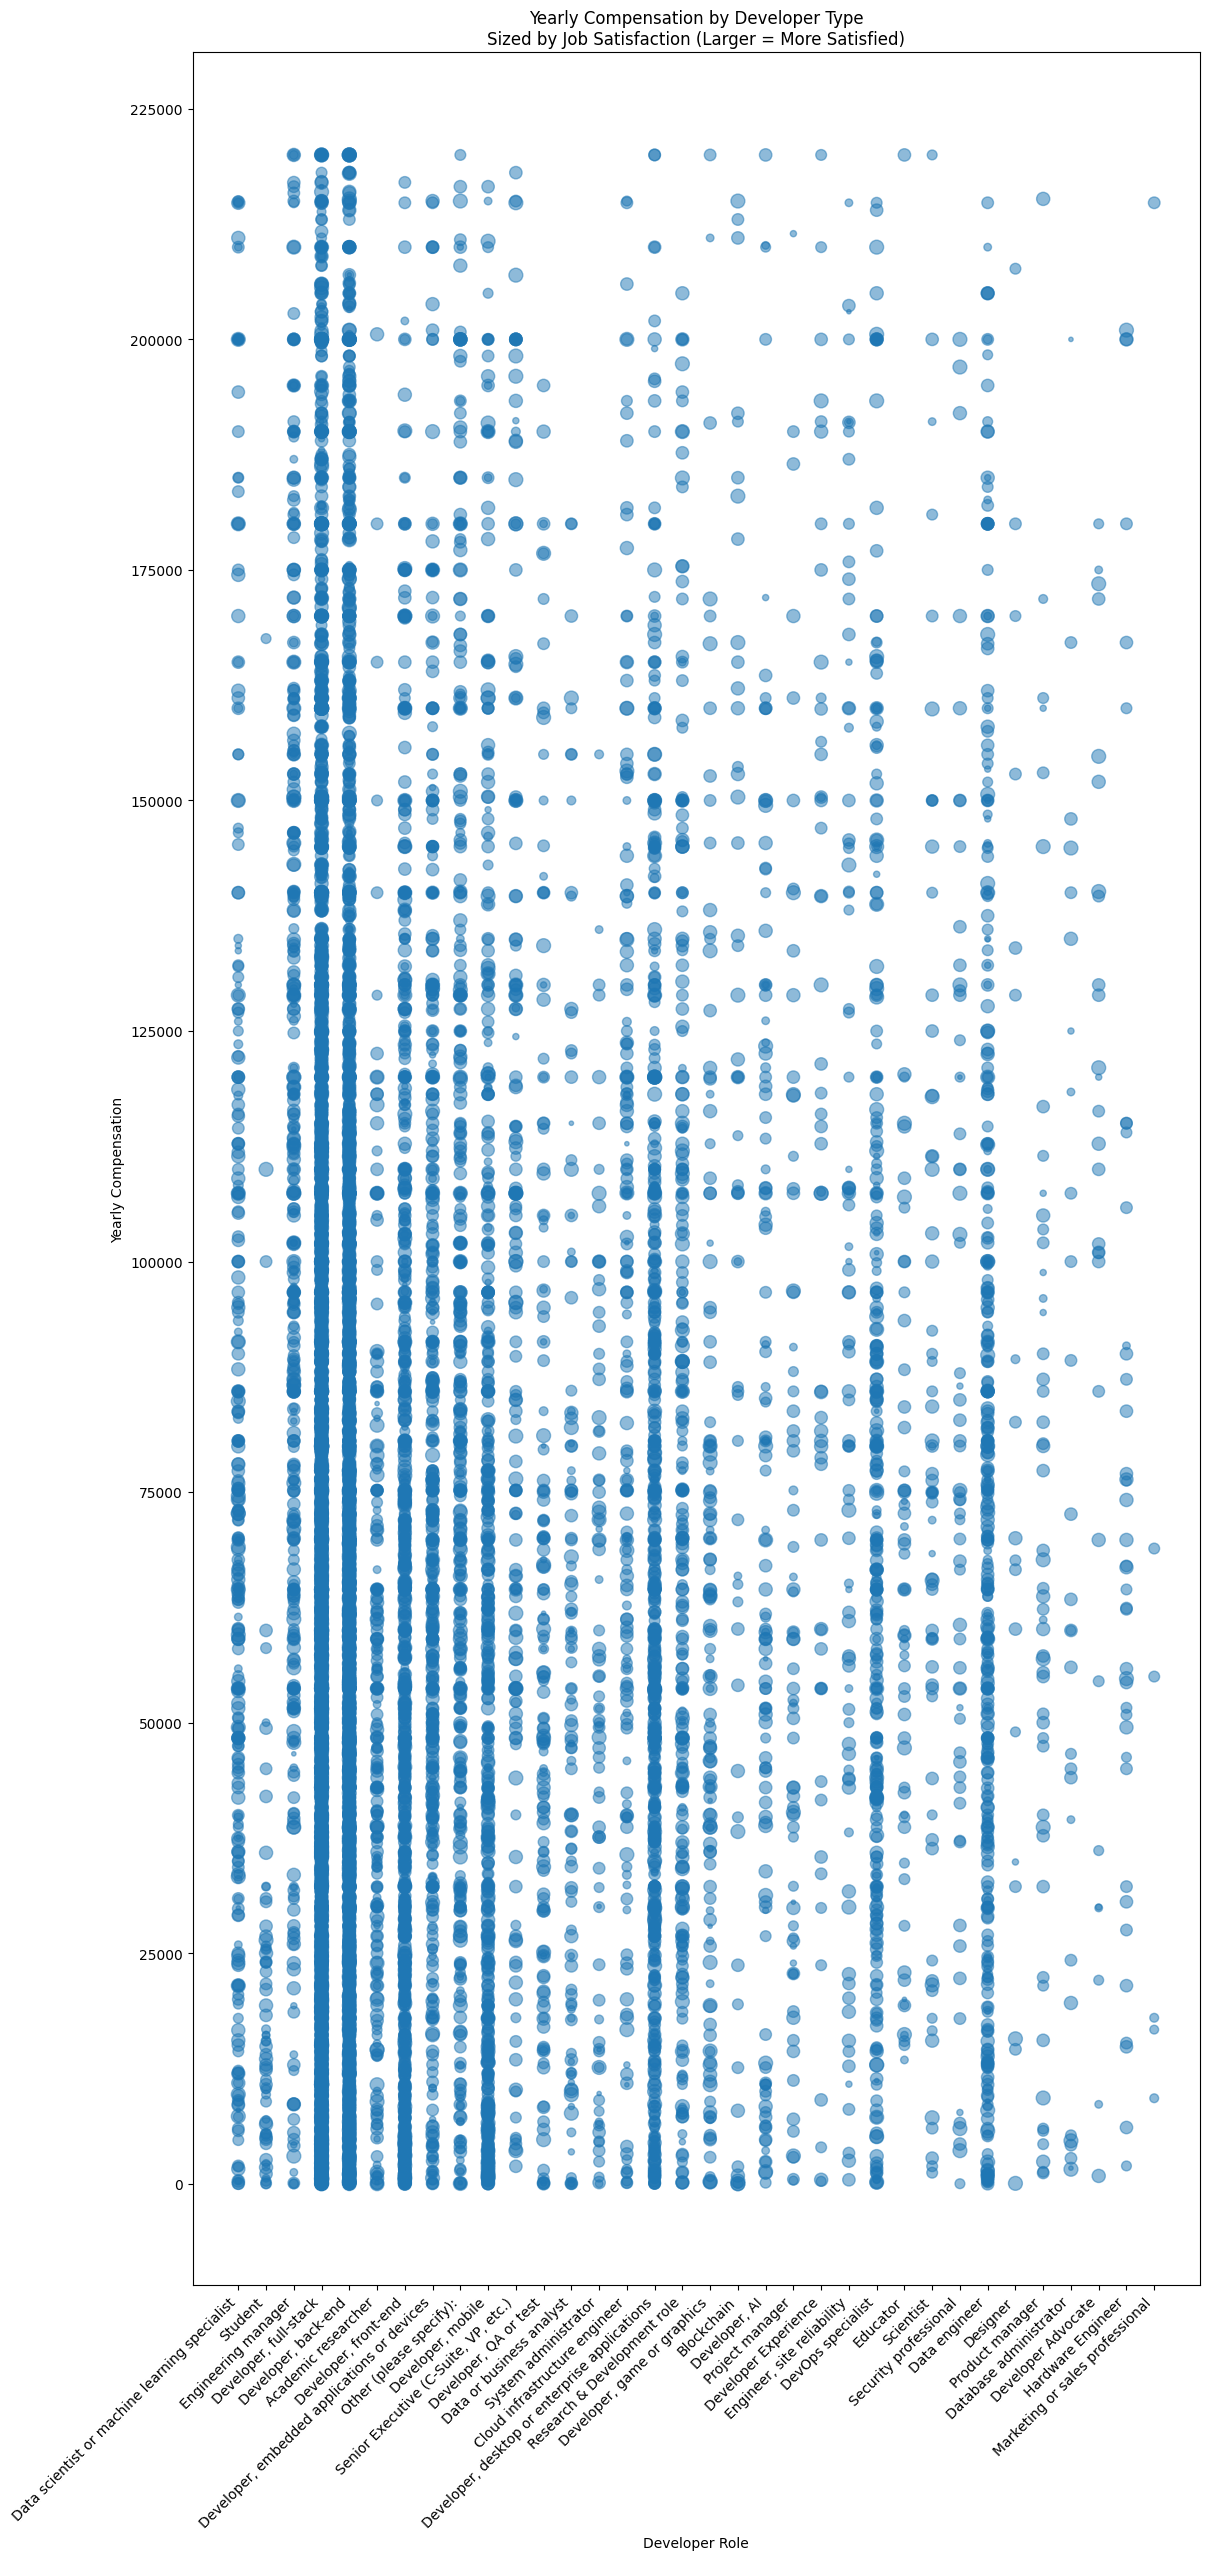

In [23]:
plt.figure(figsize = (13,29))
plt.scatter(x = bub_comp_dev['DevType'],
            y = bub_comp_dev['ConvertedCompYearly'],
            s = bub_comp_dev['JobSat']* 10,
            alpha = 0.5)
plt.xlabel('Developer Role')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Yearly Compensation')
plt.yticks(range(0, 250000, 25000))
plt.title('Yearly Compensation by Developer Type\nSized by Job Satisfaction (Larger = More Satisfied)')
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


In [24]:
bub_coll_age = df[['NEWCollabToolsHaveWorkedWith', 'Age']]
bub_coll_age = bub_coll_age.dropna()
bub_coll_age = bub_coll_age.replace('Under 18 years old', '13-17 years old') # will later have row in sequence before 18-24
bub_coll_age

,NEWCollabToolsHaveWorkedWith,Age
1,PyCharm;Visual Studio Code;WebStorm,35-44 years old
2,Visual Studio,45-54 years old
4,Vim,18-24 years old
5,Nano;Vim;Visual Studio Code;Xcode,13-17 years old
6,RStudio,35-44 years old
...,...,...
65414,Android Studio;Jupyter Notebook/JupyterLab;Vis...,18-24 years old
65421,Sublime Text;Visual Studio Code,25-34 years old
65431,DataGrip;IntelliJ IDEA;PyCharm;Rider;Sublime T...,45-54 years old
65435,Vim;Visual Studio Code,18-24 years old


In [25]:
bub_coll_age['CollabTools'] = bub_coll_age['NEWCollabToolsHaveWorkedWith'].str.split(';') # split into new column
bub_coll_age = bub_coll_age.drop('NEWCollabToolsHaveWorkedWith', axis = 1)
bub_coll_age = bub_coll_age.explode('CollabTools').reset_index(drop = True)
bub_coll_age

,Age,CollabTools
0,35-44 years old,PyCharm
1,35-44 years old,Visual Studio Code
2,35-44 years old,WebStorm
3,45-54 years old,Visual Studio
4,18-24 years old,Vim
...,...,...
196231,45-54 years old,WebStorm
196232,45-54 years old,Xcode
196233,18-24 years old,Vim
196234,18-24 years old,Visual Studio Code


In [26]:
bub_coll_age = bub_coll_age.groupby(['Age', 'CollabTools']).size().reset_index(name = 'Sizes')

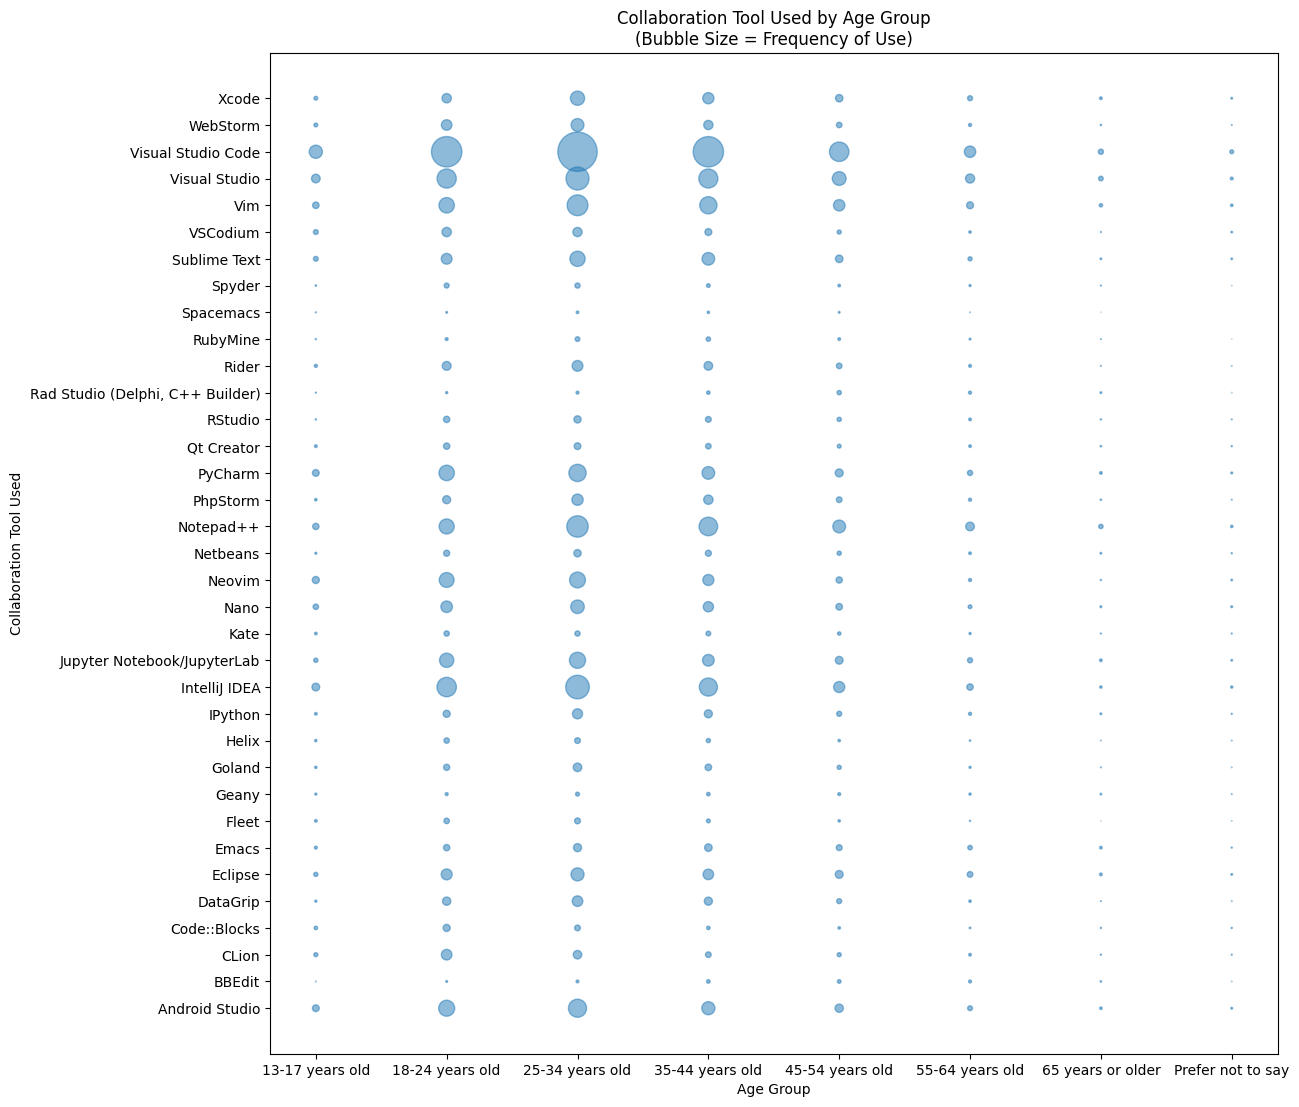

In [27]:
plt.figure(figsize = (13, 13))
plt.scatter(x = bub_coll_age['Age'],
            y = bub_coll_age['CollabTools'],
            s = bub_coll_age['Sizes']/20,
            alpha = 0.5)
plt.xlabel('Age Group')
plt.ylabel('Collaboration Tool Used')
plt.title('Collaboration Tool Used by Age Group\n(Bubble Size = Frequency of Use)')
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



In [28]:
bub_frame_sat = df[['WebframeWantToWorkWith', 'JobSat']]
bub_frame_sat = bub_frame_sat.dropna()
bub_frame_sat

,WebframeWantToWorkWith,JobSat
10,Django;Node.js;React;Ruby on Rails,8.0
15,Blazor,5.0
18,ASP.NET CORE;Blazor,10.0
20,Angular;Laravel;React,6.0
22,ASP.NET CORE,9.0
...,...,...
65161,Flask;NestJS;Next.js;Node.js;Nuxt.js;React,6.0
65163,ASP.NET;ASP.NET CORE;Next.js;Node.js,9.0
65166,Astro;Node.js;Nuxt.js;Remix;Svelte;Vue.js,8.0
65168,React;Spring Boot,7.0


In [29]:
bub_frame_sat['Webframe'] = bub_frame_sat['WebframeWantToWorkWith'].str.split(';')
bub_frame_sat = bub_frame_sat.drop('WebframeWantToWorkWith', axis = 1)
bub_frame_sat = bub_frame_sat.explode('Webframe').reset_index(drop = True)
bub_frame_sat

,JobSat,Webframe
0,8.0,Django
1,8.0,Node.js
2,8.0,React
3,8.0,Ruby on Rails
4,5.0,Blazor
...,...,...
70850,8.0,React
70851,8.0,Spring Boot
70852,8.0,Symfony
70853,8.0,Vue.js


In [30]:
bub_frame_sat = bub_frame_sat.groupby(['JobSat', 'Webframe']).size().reset_index(name = 'Sizes')
bub_frame_sat

,JobSat,Webframe,Sizes
0,0.0,ASP.NET,20
1,0.0,ASP.NET CORE,39
2,0.0,Angular,25
3,0.0,AngularJS,7
4,0.0,Astro,13
...,...,...,...
391,10.0,Symfony,63
392,10.0,Vue.js,305
393,10.0,WordPress,118
394,10.0,Yii 2,18


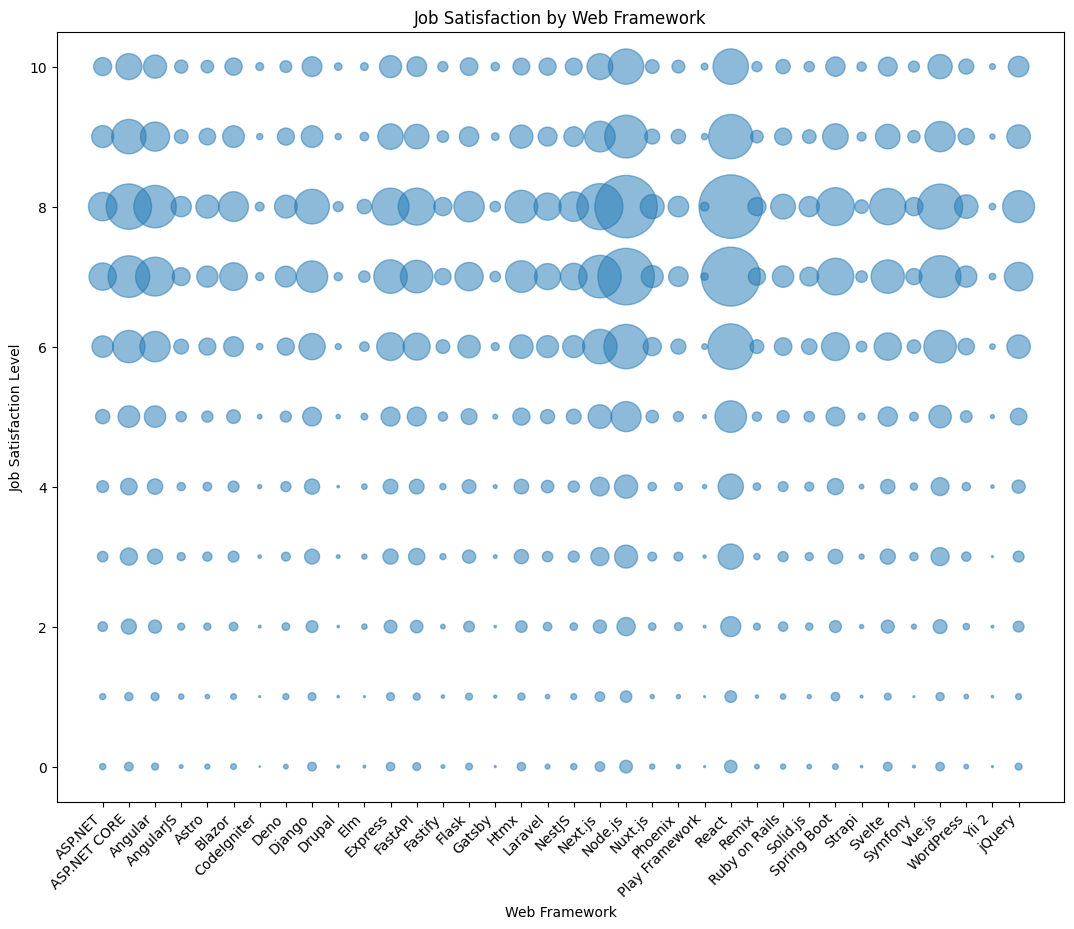

In [31]:
plt.figure(figsize = (13, 10))
plt.scatter(y = bub_frame_sat['JobSat'],
            x = bub_frame_sat['Webframe'],
            s = bub_frame_sat['Sizes'],
            alpha = 0.5)
plt.xlabel('Web Framework')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Job Satisfaction Level')
plt.title('Job Satisfaction by Web Framework')
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



In [32]:
bub_lang_country = df[['LanguageAdmired', 'Country']]
bub_lang_country = bub_lang_country.dropna()
bub_lang_country

,LanguageAdmired,Country
1,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,United Kingdom of Great Britain and Northern I...
2,C#,United Kingdom of Great Britain and Northern I...
3,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...,Canada
4,C++;HTML/CSS;JavaScript;Lua;Python,Norway
5,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,United States of America
...,...,...
65396,HTML/CSS;JavaScript;Python;TypeScript,Lithuania
65401,C#;HTML/CSS;JavaScript;SQL;TypeScript,France
65408,Python;SQL,France
65431,Bash/Shell (all shells);C#;HTML/CSS;Java;JavaS...,Belgium


In [33]:
bub_lang_country = bub_lang_country.replace({'United Kingdom of Great Britain and Northern Ireland': 'U.K.',
                                             'Iran, Islamic Republic of...': 'Iran',
                                             'United States of America': 'U.S.A.',
                                             'Russian Federation': 'Russia'}) # shortening known offenders
bub_lang_country['Lang Admired'] = bub_lang_country['LanguageAdmired'].str.split(';')
bub_lang_country = bub_lang_country.drop('LanguageAdmired', axis = 1)
bub_lang_country = bub_lang_country.explode('Lang Admired').reset_index(drop = True)
bub_lang_country

,Country,Lang Admired
0,U.K.,Bash/Shell (all shells)
1,U.K.,Go
2,U.K.,HTML/CSS
3,U.K.,Java
4,U.K.,JavaScript
...,...,...
183772,Belgium,SQL
183773,Belgium,Swift
183774,Belgium,TypeScript
183775,Germany,Rust


In [34]:
top30 = list(bub_lang_country['Country'].value_counts().head(30).index) # plotting only 30 most responsive countries
rows_to_drop = bub_lang_country.loc[bub_lang_country['Country'].isin(top30) == False] # gathering rows to drop
bub_lang_country = bub_lang_country.drop(rows_to_drop.index) # dropping rows by index

In [35]:
bub_lang_country = bub_lang_country.groupby(['Country', 'Lang Admired']).size().reset_index(name = 'Sizes')
bub_lang_country

,Country,Lang Admired,Sizes
0,Australia,Ada,4
1,Australia,Apex,4
2,Australia,Assembly,42
3,Australia,Bash/Shell (all shells),295
4,Australia,C,143
...,...,...,...
1383,Ukraine,TypeScript,711
1384,Ukraine,VBA,4
1385,Ukraine,Visual Basic (.Net),3
1386,Ukraine,Zephyr,5


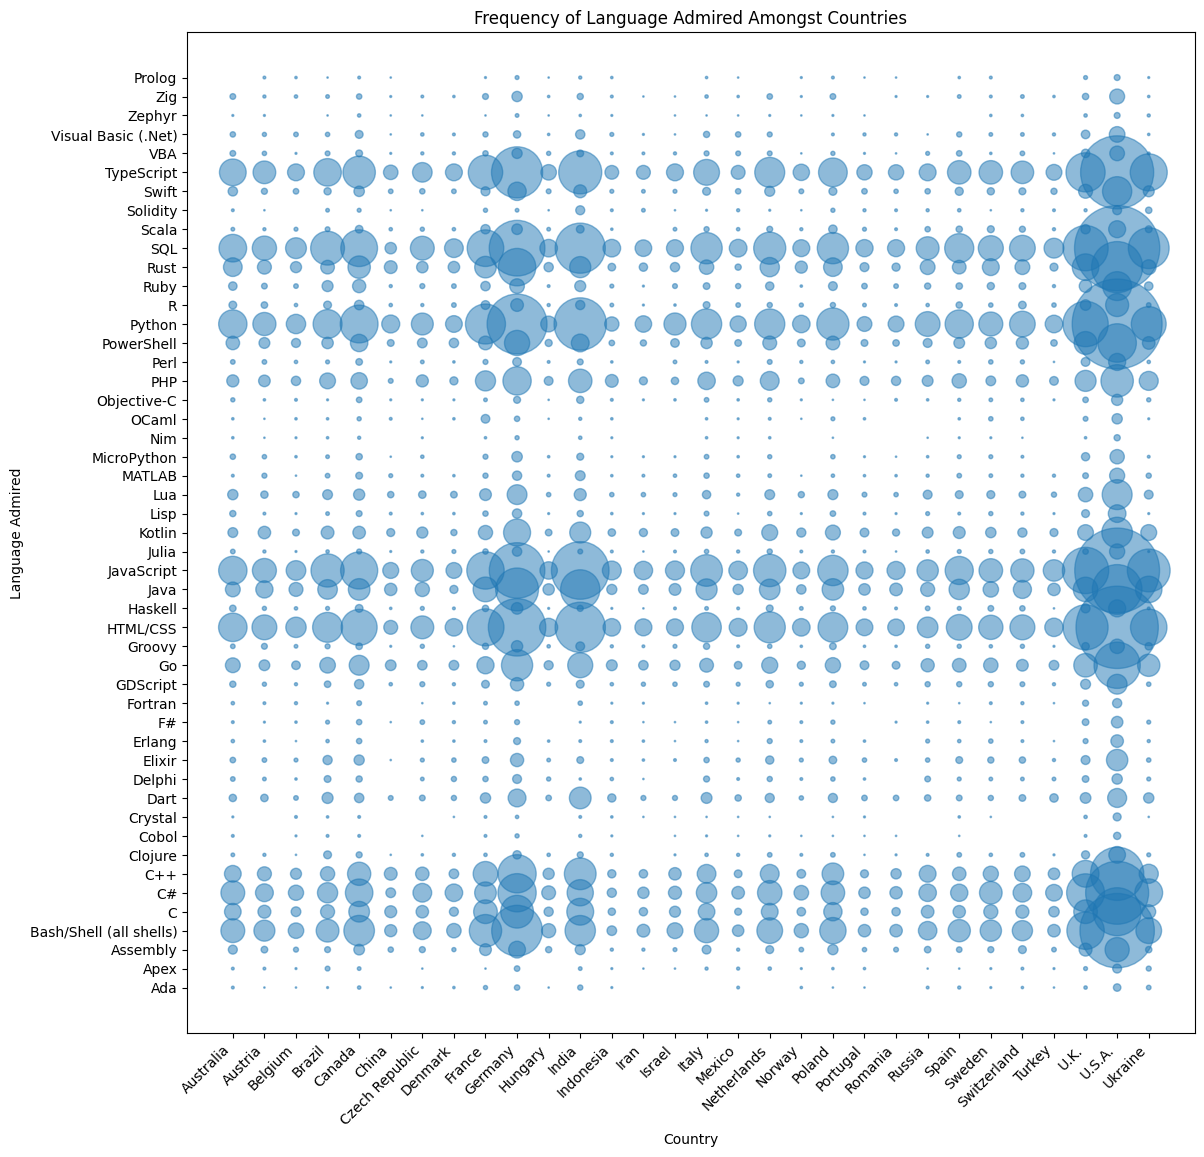

In [36]:
plt.figure(figsize = (13, 13))
plt.scatter(x = bub_lang_country['Country'],
            y = bub_lang_country['Lang Admired'],
            s = bub_lang_country['Sizes'],
            alpha = 0.5)
plt.xlabel('Country')
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel('Language Admired')
plt.title('Frequency of Language Admired Amongst Countries')
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
